# Satellite Telemetry Anomaly Detection - Exploratory Data Analysis
This notebook contains the preliminary data loading, verification, and exploratory analysis of the satellite telemetry dataset

## 1. Environment Setup

### Libraries import

In [1]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.fft import fft, fftfreq

from sklearn.preprocessing import StandardScaler, MinMaxScaler

### Reproducibility setup

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

### Plotting configurations

In [3]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

### Data paths definitions

In [4]:
RAW_DATA_DIR = "../data"
PROCESSED_DATA_DIR = "../data/processed"

DATASET_PATH  = os.path.join(RAW_DATA_DIR, "dataset.csv")
SEGMENTS_PATH = os.path.join(RAW_DATA_DIR, "segments.csv")

os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)

## 2. Global Features Dataset Exploration

In [5]:
if os.path.exists(DATASET_PATH):
    df_dataset = pd.read_csv(DATASET_PATH)
    print("DATASET (Global Features)\n")
    print(f"Observations (Rows): {df_dataset.shape[0]}")
    print(f"Features (Columns):  {df_dataset.shape[1]}\n")
    print("Detailed Summary")
    df_dataset.info()
else:
    print(f"Error: Target file not found at {DATASET_PATH}")

DATASET (Global Features)

Observations (Rows): 2123
Features (Columns):  23

Detailed Summary
<class 'pandas.DataFrame'>
RangeIndex: 2123 entries, 0 to 2122
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   segment           2123 non-null   int64  
 1   anomaly           2123 non-null   int64  
 2   train             2123 non-null   int64  
 3   channel           2123 non-null   str    
 4   sampling          2123 non-null   int64  
 5   duration          2123 non-null   int64  
 6   len               2123 non-null   int64  
 7   mean              2123 non-null   float64
 8   var               2123 non-null   float64
 9   std               2123 non-null   float64
 10  kurtosis          2123 non-null   float64
 11  skew              2123 non-null   float64
 12  n_peaks           2123 non-null   int64  
 13  smooth10_n_peaks  2123 non-null   int64  
 14  smooth20_n_peaks  2123 non-null   int64  
 15  diff_

In [6]:
if os.path.exists(SEGMENTS_PATH):
    df_segments = pd.read_csv(SEGMENTS_PATH)
    print("Segments (Raw Time-Series)\n")
    print(f"Temporal Points (Rows): {df_segments.shape[0]}")
    print(f"Variables (Columns):    {df_segments.shape[1]}\n")
    
    df_segments['timestamp'] = pd.to_datetime(df_segments['timestamp'])
    df_segments = df_segments.sort_values(by=['channel', 'segment', 'timestamp']).reset_index(drop=True)
    missing_count = df_segments.isnull().sum().sum()
    print(f"Timestamp parsing complete. Data type: {df_segments['timestamp'].dtype}")
    print(f"Total missing values in time-series: {missing_count}\n")

    display(df_segments.head()) 
else:
    print(f"Error: Target file not found at {SEGMENTS_PATH}")

Segments (Raw Time-Series)

Temporal Points (Rows): 303493
Variables (Columns):    8

Timestamp parsing complete. Data type: datetime64[us, UTC]
Total missing values in time-series: 0



,channel,timestamp,value,label,sampling,anomaly,segment,train
0,CADC0872,2022-06-01 23:42:54+00:00,-0.000021,anomaly,1,1,1,1
1,CADC0872,2022-06-01 23:42:55+00:00,-0.000021,anomaly,1,1,1,1
2,CADC0872,2022-06-01 23:42:56+00:00,-0.000021,anomaly,1,1,1,1
3,CADC0872,2022-06-01 23:42:57+00:00,-0.000021,anomaly,1,1,1,1
4,CADC0872,2022-06-01 23:42:58+00:00,-0.000021,anomaly,1,1,1,1


## 3. Dataset Properties

### Utility functions for dataset profiling

In [7]:
def compute_column_statistics(df, column, title):
    if column not in df.columns:
        print(f"Error: Required column '{column}' not found.")
        return
    print(f"{title} analysis")
    print(f"Total samples: {len(df[column])}")
    print(f"Unique values: {df[column].nunique()}")
    print("\nValue Counts:")
    print(df[column].value_counts())
    print("\nPercentages:")
    print(df[column].value_counts(normalize=True) * 100)

def generate_property_plot(df, column, title, plot_type='count', hue_col=None, labels=None, order=None, xlabel=None):
    if column not in df.columns:
        print(f"Error: Required column '{column}' not found.")
        return
    
    plt.figure()
    
    if plot_type == 'count':
        if hue_col:
            sns.countplot(data=df, x=column, hue=hue_col, order=order, palette=['royalblue', 'crimson'])
        else:
            sns.countplot(data=df, x=column, order=order, hue=column, palette=['royalblue', 'crimson'], legend=False)
        
        if labels:
            plt.gca().set_xticks(range(len(labels)))
            plt.gca().set_xticklabels(labels)
            
    elif plot_type == 'bar_horizontal':
        top_values = df[column].value_counts().head(10)
        sns.barplot(x=top_values.values, y=top_values.index, hue=top_values.index, palette="viridis", legend=False)
        
    plt.title(title, fontsize=12, pad=10)
    plt.xlabel(xlabel if xlabel else column.capitalize())
    plt.ylabel("Count")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

### High-Level Dataset Profiling

Target Class Distribution analysis
Total samples: 2123
Unique values: 2

Value Counts:
anomaly
0    1689
1     434
Name: count, dtype: int64

Percentages:
anomaly
0    79.55723
1    20.44277
Name: proportion, dtype: float64


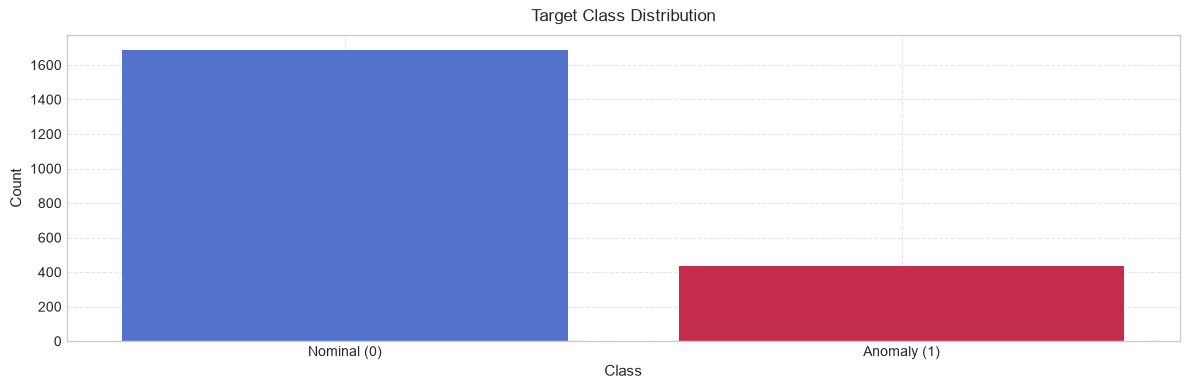

Train / Test Split analysis
Total samples: 2123
Unique values: 2

Value Counts:
train
1    1594
0     529
Name: count, dtype: int64

Percentages:
train
1    75.082431
0    24.917569
Name: proportion, dtype: float64


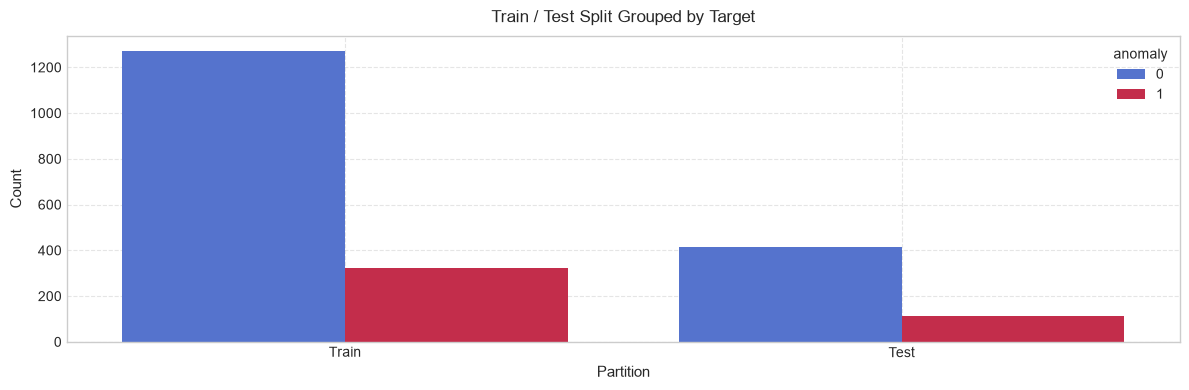

Telemetry Channels analysis
Total samples: 2123
Unique values: 9

Value Counts:
channel
CADC0873    593
CADC0872    546
CADC0888    252
CADC0892    211
CADC0874    194
CADC0884    158
CADC0894    144
CADC0890     14
CADC0886     11
Name: count, dtype: int64

Percentages:
channel
CADC0873    27.932171
CADC0872    25.718323
CADC0888    11.869995
CADC0892     9.938766
CADC0874     9.138012
CADC0884     7.442299
CADC0894     6.782854
CADC0890     0.659444
CADC0886     0.518135
Name: proportion, dtype: float64


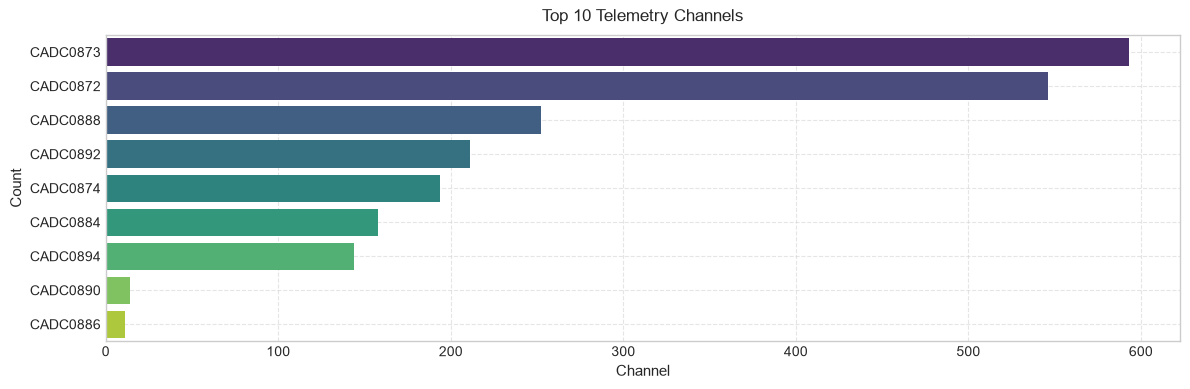

In [8]:
compute_column_statistics(df_dataset, 'anomaly', 'Target Class Distribution')
generate_property_plot(df_dataset, 'anomaly', 'Target Class Distribution', plot_type='count', labels=['Nominal (0)', 'Anomaly (1)'], xlabel="Class")

compute_column_statistics(df_dataset, 'train', 'Train / Test Split')
generate_property_plot(df_dataset, 'train', 'Train / Test Split Grouped by Target', plot_type='count', hue_col='anomaly', order=[1, 0], labels=['Train', 'Test'], xlabel="Partition")

compute_column_statistics(df_dataset, 'channel', 'Telemetry Channels')
generate_property_plot(df_dataset, 'channel', 'Top 10 Telemetry Channels', plot_type='bar_horizontal')

### Advanced Time-Series Profiling

In [9]:
def analyze_time_delta_and_gaps(df_seg):
    df_copy = df_seg.copy()
    df_copy['delta_t'] = df_copy.groupby(['channel', 'segment'])['timestamp'].diff().dt.total_seconds()
    
    print("Temporal sampling and Gap analysis")
    print(f"Average Delta-T: {df_copy['delta_t'].mean():.4f} seconds")
    print(f"Median Delta-T:  {df_copy['delta_t'].median():.4f} seconds")
    print(f"Min Delta-T:     {df_copy['delta_t'].min():.4f} seconds")
    print(f"Max Delta-T:     {df_copy['delta_t'].max():.4f} seconds")
    
    gaps = df_copy[df_copy['delta_t'] > 1.0]
    print(f"\nTotal sampling gaps detected (> 1.0s): {len(gaps)}")
    print("\nTop 5 Sampling Intervals Frequencies:")
    print(df_copy['delta_t'].value_counts().head(5))

    plt.figure()
    ax = sns.histplot(
        df_copy['delta_t'].dropna(),
        binwidth=1,
        binrange=(0, 10),
        color='royalblue',
        edgecolor='black',
        alpha=0.7
    )
    
    plt.title("Sampling Interval ($\Delta t$) Distribution (0 - 10s)", fontsize=12, pad=10)
    plt.xlabel("Seconds between consecutive samples ($\Delta t$)")
    plt.ylabel("Frequency (Number of Samples)")
    plt.xticks(range(0, 11))

    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

def analyze_segment_lengths(df_seg):

    seg_lengths = df_seg.groupby(['channel', 'segment', 'anomaly']).size().reset_index(name='point_count')
    
    print("Segment length statistics")
    print(f"Total Segments: {len(seg_lengths)}")
    print(f"Average points per segment: {seg_lengths['point_count'].mean():.2f}")
    print(f"Min points in a segment:    {seg_lengths['point_count'].min()}")
    print(f"Max points in a segment:    {seg_lengths['point_count'].max()}")
    print("\nSequence Length Summary by Class:")
    print(seg_lengths.groupby('anomaly')['point_count'].describe())

    plt.figure()
    sns.boxplot(data=seg_lengths, x='anomaly', y='point_count', hue='anomaly', palette=['royalblue', 'crimson'], legend=False)
    plt.gca().set_xticks([0, 1])
    plt.gca().set_xticklabels(['Nominal (0)', 'Anomaly (1)'])
    plt.title("Sequence Length Distribution per Segment by Class", fontsize=12)
    plt.xlabel("Class")
    plt.ylabel("Number of Time Steps")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

Temporal sampling and Gap analysis
Average Delta-T: 1.8876 seconds
Median Delta-T:  1.0000 seconds
Min Delta-T:     0.0000 seconds
Max Delta-T:     130.0000 seconds

Total sampling gaps detected (> 1.0s): 91951

Top 5 Sampling Intervals Frequencies:
delta_t
1.0    187304
5.0     63680
2.0     26941
0.0     22115
6.0       693
Name: count, dtype: int64


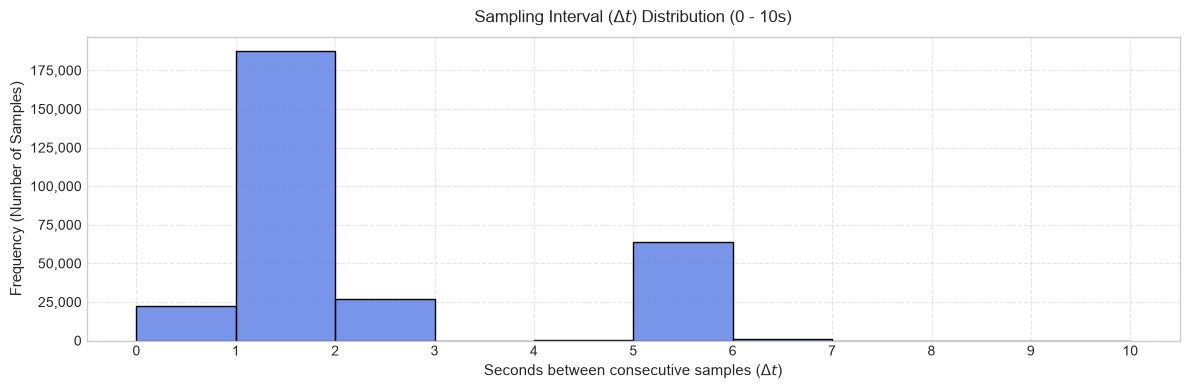

Segment length statistics
Total Segments: 2123
Average points per segment: 142.95
Min points in a segment:    8
Max points in a segment:    1040

Sequence Length Summary by Class:
          count        mean         std   min    25%    50%    75%     max
anomaly                                                                   
0        1689.0  120.325044  131.655155   8.0  35.00   54.0  184.0   827.0
1         434.0  231.023041  190.722243  10.0  61.25  184.5  354.5  1040.0


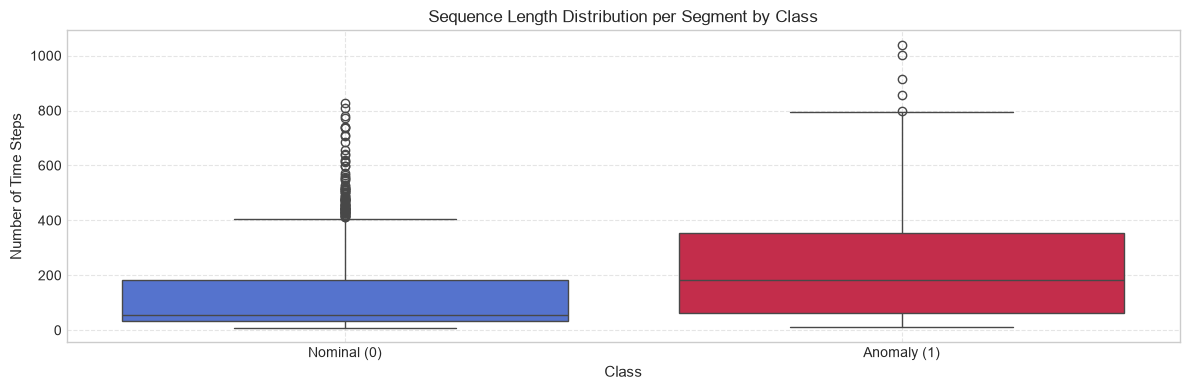

In [10]:
analyze_time_delta_and_gaps(df_segments)
analyze_segment_lengths(df_segments)

## 4. Data Cleaning, Normalization & Feature Pipeline

In [11]:
def fit_and_apply_scalers(df_seg, feature_col='value', scaler_type='standard'):

    df_scaled = df_seg.copy()
    df_scaled[f'{feature_col}_scaled'] = np.nan
    
    scalers_dict = {}
    channels = df_seg['channel'].unique()
    
    print(f"Normalization pipeline ({scaler_type} scaler)")
    
    for ch in channels:
        train_nominal_mask = (df_seg['channel'] == ch) & (df_seg['train'] == 1) & (df_seg['anomaly'] == 0)
        channel_mask = (df_seg['channel'] == ch)
        
        train_nominal_vals = df_seg.loc[train_nominal_mask, [feature_col]].values
        
        if len(train_nominal_vals) == 0:
            print(f"Warning: No nominal training samples found for channel {ch}. Skipping.")
            continue

        if scaler_type == 'standard':
            scaler = StandardScaler()
        elif scaler_type == 'minmax':
            scaler = MinMaxScaler(feature_range=(-1, 1))
        else:
            raise ValueError("Unsupported scaler type. Choose 'standard' or 'minmax'.")

        scaler.fit(train_nominal_vals)
        scalers_dict[ch] = scaler

        all_channel_vals = df_seg.loc[channel_mask, [feature_col]].values
        df_scaled.loc[channel_mask, f'{feature_col}_scaled'] = scaler.transform(all_channel_vals)
        
        print(f"Channel {ch:<10} | Fit Samples (Train Nominal): {len(train_nominal_vals):<6} | Mean: {scaler.mean_[0]:8.4f} | Std: {np.sqrt(scaler.var_[0]):8.4f}")
        
    print("\nNormalization complete. Scaled feature added: 'value_scaled'")
    
    return df_scaled, scalers_dict

df_segments_clean, channel_scalers = fit_and_apply_scalers(df_segments, feature_col='value', scaler_type='standard')
display(df_segments_clean[['channel', 'timestamp', 'value', 'value_scaled', 'anomaly', 'train']].head())

Normalization pipeline (standard scaler)
Channel CADC0872   | Fit Samples (Train Nominal): 32718  | Mean:   0.0000 | Std:   0.0000
Channel CADC0873   | Fit Samples (Train Nominal): 35404  | Mean:  -0.0000 | Std:   0.0000
Channel CADC0874   | Fit Samples (Train Nominal): 17880  | Mean:   0.0000 | Std:   0.0000
Channel CADC0884   | Fit Samples (Train Nominal): 9121   | Mean:   0.4715 | Std:   0.3883
Channel CADC0886   | Fit Samples (Train Nominal): 190    | Mean:   0.1743 | Std:   0.2256
Channel CADC0888   | Fit Samples (Train Nominal): 6446   | Mean:   0.2815 | Std:   0.3562
Channel CADC0890   | Fit Samples (Train Nominal): 147    | Mean:   0.3697 | Std:   0.3839
Channel CADC0892   | Fit Samples (Train Nominal): 30936  | Mean:   0.2700 | Std:   0.3437
Channel CADC0894   | Fit Samples (Train Nominal): 20857  | Mean:   0.1314 | Std:   0.2273

Normalization complete. Scaled feature added: 'value_scaled'


,channel,timestamp,value,value_scaled,anomaly,train
0,CADC0872,2022-06-01 23:42:54+00:00,-0.000021,-1.010056,1,1
1,CADC0872,2022-06-01 23:42:55+00:00,-0.000021,-0.965855,1,1
2,CADC0872,2022-06-01 23:42:56+00:00,-0.000021,-0.990932,1,1
3,CADC0872,2022-06-01 23:42:57+00:00,-0.000021,-1.009889,1,1
4,CADC0872,2022-06-01 23:42:58+00:00,-0.000021,-1.009889,1,1


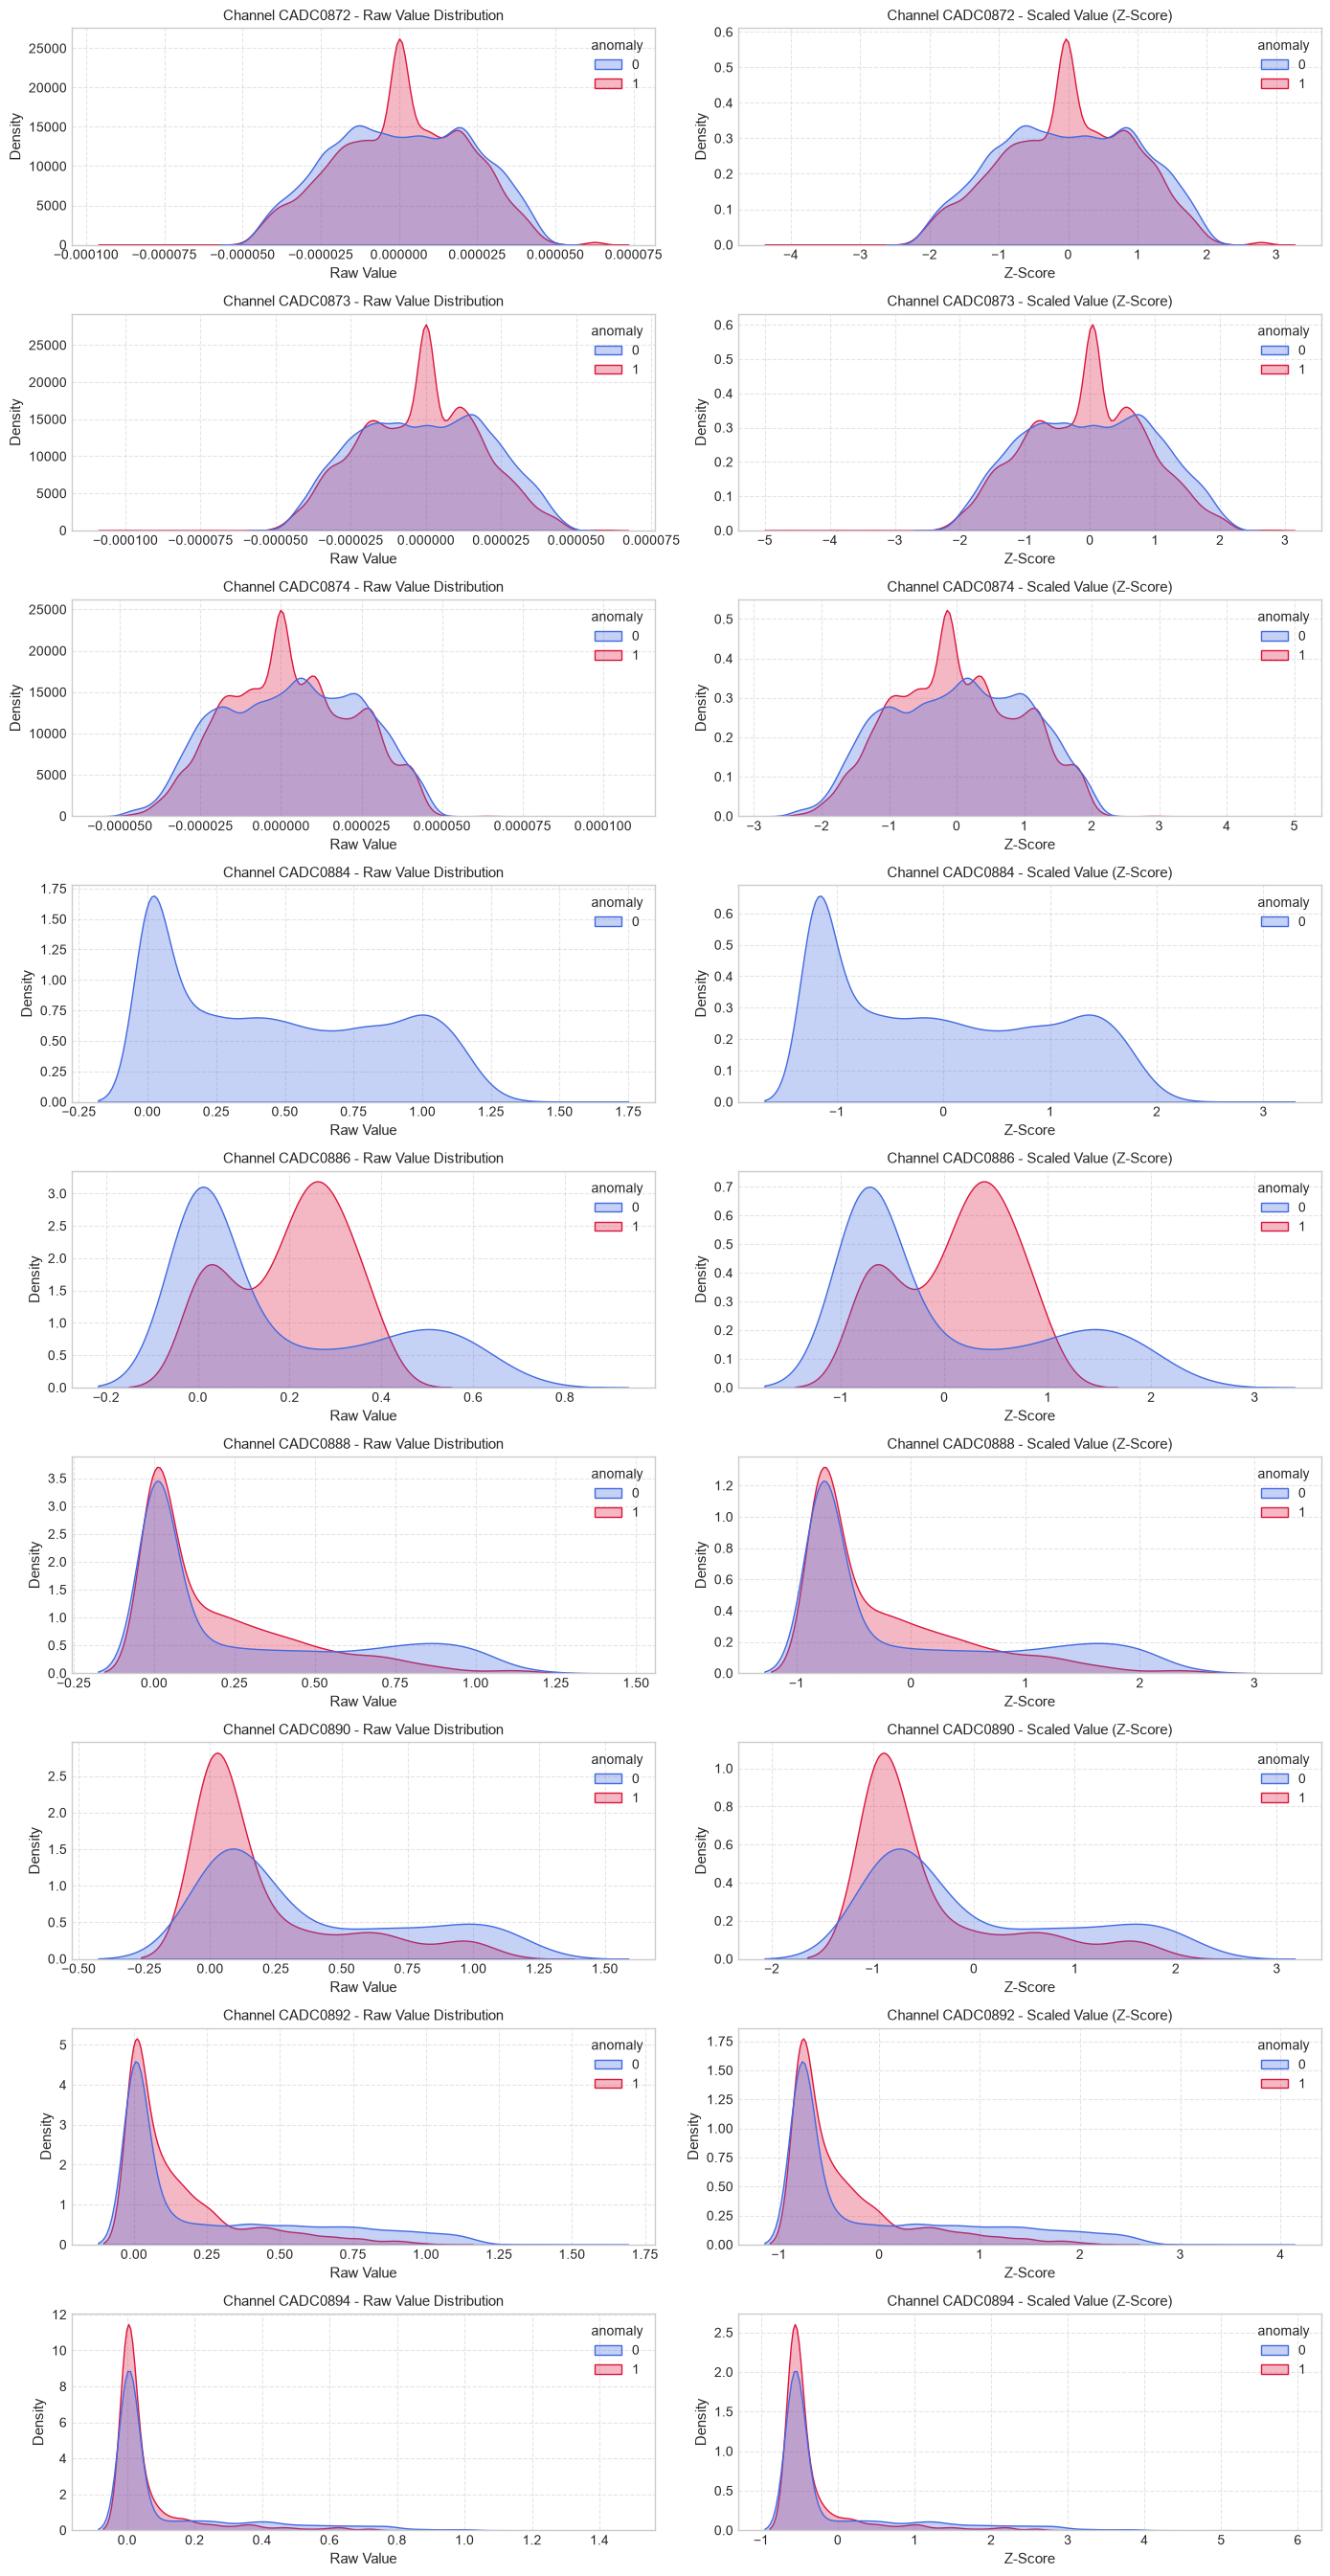

In [12]:
channels = df_segments_clean['channel'].unique()
fig, axes = plt.subplots(len(channels), 2, figsize=(14, 3 * len(channels)))

color_dict = {0: 'royalblue', 1: 'crimson'}

for i, ch in enumerate(channels):
    ch_df = df_segments_clean[df_segments_clean['channel'] == ch]

    sns.kdeplot(
        data=ch_df, x='value', hue='anomaly', ax=axes[i, 0], 
        palette=color_dict, common_norm=False, fill=True, alpha=0.3
    )
    axes[i, 0].set_title(f"Channel {ch} - Raw Value Distribution", fontsize=11)
    axes[i, 0].set_xlabel("Raw Value")
    axes[i, 0].grid(True, linestyle='--', alpha=0.5)

    sns.kdeplot(
        data=ch_df, x='value_scaled', hue='anomaly', ax=axes[i, 1], 
        palette=color_dict, common_norm=False, fill=True, alpha=0.3
    )
    axes[i, 1].set_title(f"Channel {ch} - Scaled Value (Z-Score)", fontsize=11)
    axes[i, 1].set_xlabel("Z-Score")
    axes[i, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

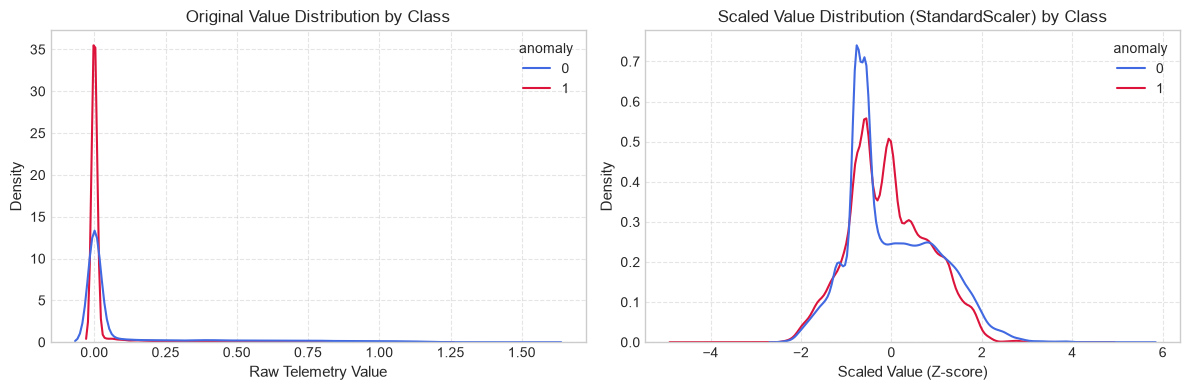

In [13]:
fig, axes = plt.subplots(1, 2)

sns.kdeplot(data=df_segments_clean, x='value', hue='anomaly', ax=axes[0], palette=['royalblue', 'crimson'], common_norm=False)
axes[0].set_title("Original Value Distribution by Class", fontsize=12)
axes[0].set_xlabel("Raw Telemetry Value")
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.kdeplot(data=df_segments_clean, x='value_scaled', hue='anomaly', ax=axes[1], palette=['royalblue', 'crimson'], common_norm=False)
axes[1].set_title("Scaled Value Distribution (StandardScaler) by Class", fontsize=12)
axes[1].set_xlabel("Scaled Value (Z-score)")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 5. Advanced Time-Series Analysis & Spectral Profiling

### 5.1 Time-Series Visual Inspection with Anomaly Highlighting

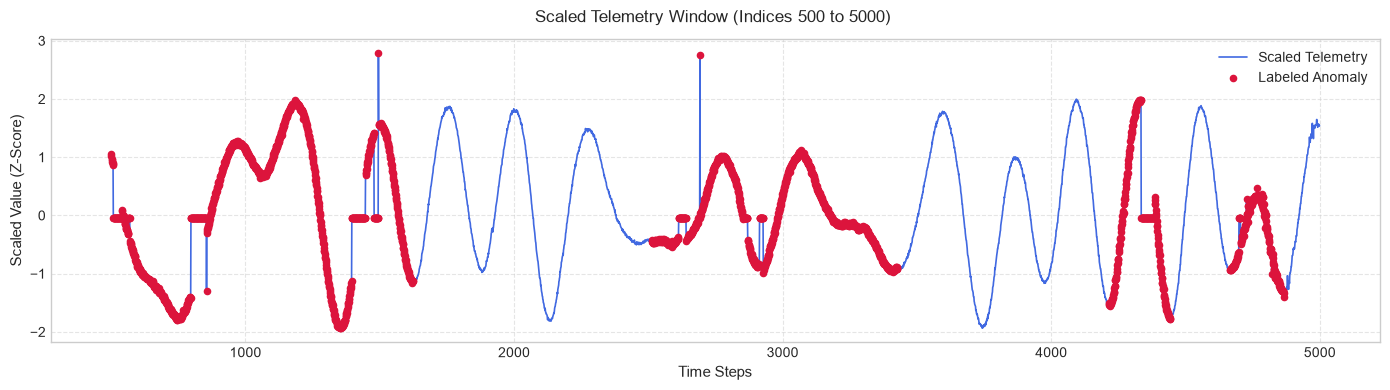

Window Statistics (indices 500-5000):
Nominal points (0): 2031
Anomalous points (1): 2469



In [14]:
def plot_telemetry_signal(df, column='value_scaled', target_col='anomaly', start=0, end=2000, title_suffix=""):

    if column not in df.columns:
        print(f"Error: Column '{column}' not found.")
        return

    sub_df = df.iloc[start:end].copy()
    plt.figure(figsize=(14, 4))
    plt.plot(range(start, end), sub_df[column].values, color='royalblue', linewidth=1.2, label='Scaled Telemetry')

    anomaly_mask = (sub_df[target_col] == 1).values
    anomaly_indices = np.where(anomaly_mask)[0] + start
    
    if len(anomaly_indices) > 0:
        plt.scatter(anomaly_indices, df[column].iloc[anomaly_indices].values, color='crimson', s=20, zorder=3, label='Labeled Anomaly')
        
    plt.title(f"Scaled Telemetry Window (Indices {start} to {end}) {title_suffix}", fontsize=12, pad=12)
    plt.xlabel("Time Steps", fontsize=11)
    plt.ylabel("Scaled Value (Z-Score)", fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    
    print(f"Window Statistics (indices {start}-{end}):")
    print(f"Nominal points (0): {(sub_df[target_col] == 0).sum()}")
    print(f"Anomalous points (1): {(sub_df[target_col] == 1).sum()}\n")

plot_telemetry_signal(df_segments_clean, column='value_scaled', start=500, end=5000)

### 5.2 Stationarity, Autocorrelation, and Memory Profiling

Augmented Dickey-Fuller test (Segment 1)
ADF Statistic: -0.793793
p-value:       8.209386e-01
Critical Values:
   1% : -3.4555
   5% : -2.8726
   10%: -2.5727
Conclusion: The sequence is non-stationary (p-value >= 0.05).


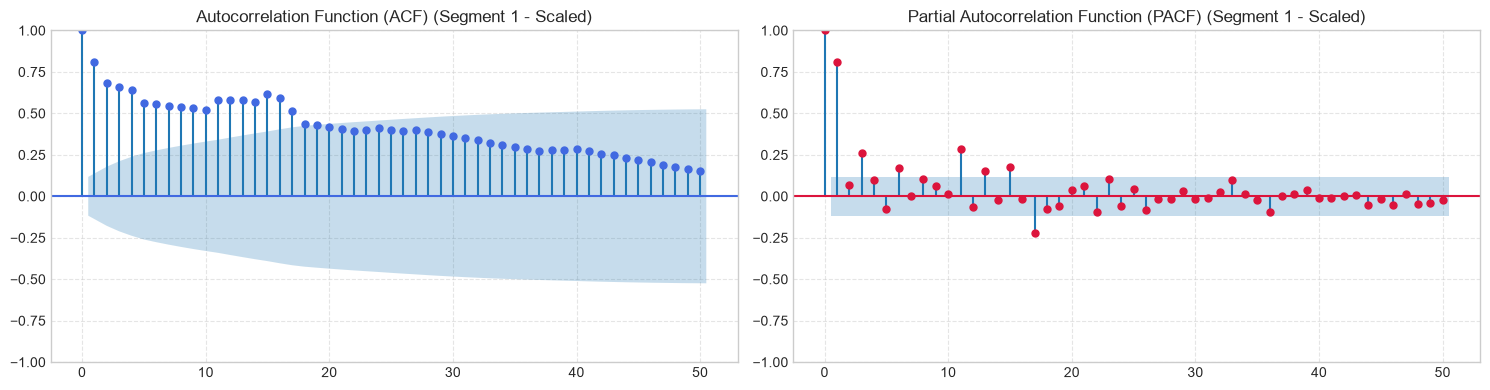

In [15]:
def check_segment_stationarity(series, segment_id=1):

    clean_series = series.dropna()
    result = adfuller(clean_series)
    
    print(f"Augmented Dickey-Fuller test (Segment {segment_id})")
    print(f"ADF Statistic: {result[0]:.6f}")
    print(f"p-value:       {result[1]:.6e}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key:<3}: {value:.4f}")
        
    if result[1] < 0.05:
        print("Conclusion: The sequence is stationary (p-value < 0.05).")
    else:
        print("Conclusion: The sequence is non-stationary (p-value >= 0.05).")

def plot_signal_autocorrelation(series, lags=50, title=""):

    clean_series = series.dropna()
    _, axes = plt.subplots(1, 2, figsize=(15, 4))
    
    plot_acf(clean_series, lags=lags, ax=axes[0], color='royalblue', alpha=0.05)
    axes[0].set_title(f"Autocorrelation Function (ACF) {title}", fontsize=12)
    axes[0].grid(True, linestyle='--', alpha=0.5)
    
    plot_pacf(clean_series, lags=lags, ax=axes[1], color='crimson', alpha=0.05)
    axes[1].set_title(f"Partial Autocorrelation Function (PACF) {title}", fontsize=12)
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

sample_segment = df_segments_clean[df_segments_clean['segment'] == 1]['value_scaled']

check_segment_stationarity(sample_segment, segment_id=1)
plot_signal_autocorrelation(sample_segment, lags=50, title="(Segment 1 - Scaled)")

### 5.3 Frequency Domain Analysis (FFT Spectrum)

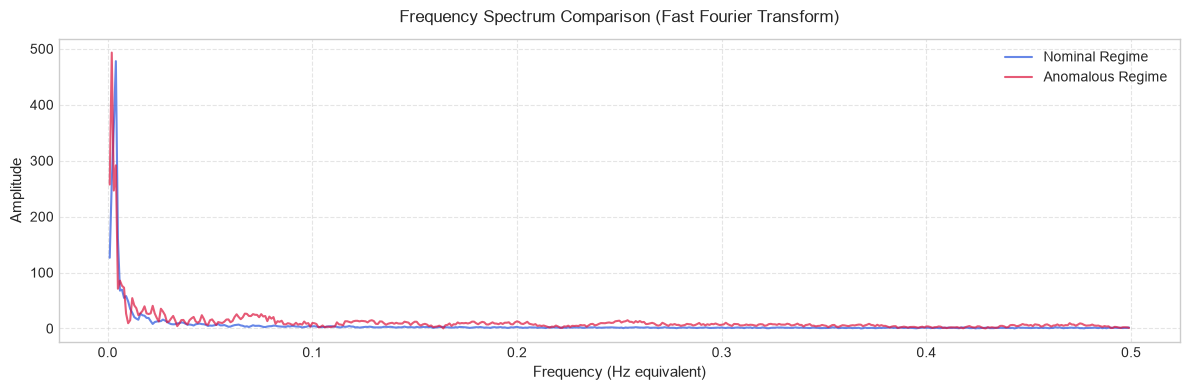

In [16]:
def plot_comparative_fft(df, window_size=1000):

    nominal_sub = df[df['anomaly'] == 0]['value_scaled'].dropna().iloc[:window_size].values
    anomalous_sub = df[df['anomaly'] == 1]['value_scaled'].dropna().iloc[:window_size].values
    
    if len(nominal_sub) < window_size or len(anomalous_sub) < window_size:
        print("Warning: Insufficient sample size for comparative FFT.")
        return

    fft_nom = fft(nominal_sub)
    freq_nom = fftfreq(window_size, d=1.0)
    pos_mask_nom = freq_nom > 0

    fft_anom = fft(anomalous_sub)
    freq_anom = fftfreq(window_size, d=1.0)
    pos_mask_anom = freq_anom > 0

    plt.figure(figsize=(12, 4))
    plt.plot(freq_nom[pos_mask_nom], np.abs(fft_nom)[pos_mask_nom], color='royalblue', linewidth=1.5, label='Nominal Regime', alpha=0.8)
    plt.plot(freq_anom[pos_mask_anom], np.abs(fft_anom)[pos_mask_anom], color='crimson', linewidth=1.5, label='Anomalous Regime', alpha=0.7)
    
    plt.title("Frequency Spectrum Comparison (Fast Fourier Transform)", fontsize=12, pad=12)
    plt.xlabel("Frequency (Hz equivalent)", fontsize=11)
    plt.ylabel("Amplitude", fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

plot_comparative_fft(df_segments_clean, window_size=1000)

## 6. Sequence Formatting & Sliding Window Generation for Deep Learning Models

### 6.1 Sliding Window Generation Function

In [17]:
def create_sliding_windows(df, feature_col='value_scaled', window_size=50, stride=1):

    X_list = []
    y_list = []
    meta_list = []

    grouped = df.groupby(['channel', 'segment'])
    
    for (ch, seg), group in grouped:
        values = group[feature_col].values
        labels = group['anomaly'].values
        n_points = len(values)
        
        if n_points < window_size:
            continue
            
        for start_idx in range(0, n_points - window_size + 1, stride):
            end_idx = start_idx + window_size

            window_vals = values[start_idx:end_idx]

            window_label = 1 if np.any(labels[start_idx:end_idx] == 1) else 0
            
            X_list.append(window_vals)
            y_list.append(window_label)
            meta_list.append({'channel': ch, 'segment': seg, 'start_idx': start_idx})
            
    X_array = np.array(X_list)[..., np.newaxis]
    y_array = np.array(y_list)
    
    return X_array, y_array, pd.DataFrame(meta_list)

WINDOW_SIZE = 50
STRIDE = 1

df_train = df_segments_clean[df_segments_clean['train'] == 1].copy()
df_test  = df_segments_clean[df_segments_clean['train'] == 0].copy()

X_train, y_train, meta_train = create_sliding_windows(df_train, feature_col='value_scaled', window_size=WINDOW_SIZE, stride=STRIDE)
X_test, y_test, meta_test    = create_sliding_windows(df_test, feature_col='value_scaled', window_size=WINDOW_SIZE, stride=STRIDE)

print("Sliding window generation summary")
print(f"Window Size (W): {WINDOW_SIZE} | Stride (S): {STRIDE}\n")
print(f"X_train Shape: {X_train.shape}  | Anomalous Windows: {y_train.sum()} / {len(y_train)} ({y_train.mean()*100:.2f}%)")
print(f"X_test Shape:  {X_test.shape}   | Anomalous Windows: {y_test.sum()} / {len(y_test)} ({y_test.mean()*100:.2f}%)")

Sliding window generation summary
Window Size (W): 50 | Stride (S): 1

X_train Shape: (158486, 50, 1)  | Anomalous Windows: 56643 / 158486 (35.74%)
X_test Shape:  (56580, 50, 1)   | Anomalous Windows: 23602 / 56580 (41.71%)


### 6.2 Preprocessed Data Export

In [18]:

train_x_path = os.path.join(PROCESSED_DATA_DIR, f"X_train_w{WINDOW_SIZE}.npy")
train_y_path = os.path.join(PROCESSED_DATA_DIR, f"y_train_w{WINDOW_SIZE}.npy")
test_x_path  = os.path.join(PROCESSED_DATA_DIR, f"X_test_w{WINDOW_SIZE}.npy")
test_y_path  = os.path.join(PROCESSED_DATA_DIR, f"y_test_w{WINDOW_SIZE}.npy")

np.save(train_x_path, X_train)
np.save(train_y_path, y_train)
np.save(test_x_path, X_test)
np.save(test_y_path, y_test)

cleaned_df_path = os.path.join(PROCESSED_DATA_DIR, "segments_cleaned_scaled.csv")
df_segments_clean.to_csv(cleaned_df_path, index=False)

print("Export completed succeffully")
print(f"Train Windows Saved to: {train_x_path}")
print(f"Test Windows Saved to:  {test_x_path}")
print(f"Cleaned CSV Saved to:   {cleaned_df_path}")

Export completed succeffully
Train Windows Saved to: ../data/processed/X_train_w50.npy
Test Windows Saved to:  ../data/processed/X_test_w50.npy
Cleaned CSV Saved to:   ../data/processed/segments_cleaned_scaled.csv
